# 16 -- N=64 reconstruction: new non-rectangular scan vs old rectangular scan

Reconstructs the N=64 GW spectrum (same bubble realization, same
`data/weights_out_N64.h5` collision weights as `06_n64_reconstruction.ipynb`)
using the `data/runtime_scan_lb0.84_gs1-4_kR1-100_nw32` scan (produced by
`15_runtime_scan_setup.ipynb`), and compares it against the reconstruction
from the older rectangular `data/phi4_lambda_bar0.84/scan_cache.h5` scan used
in notebook 06.

**The two scans differ in more than just the `(gamma_ij, t)` domain shape:**
- Old scan (`01_scan.ipynb`): fixed `gammas=linspace(1,8,32)`, `dz=0.005`,
  and a mass-scale-based frequency ceiling
  `wmax=min(10*M, pi/dz)` -- the same wide w range for every gamma_ij.
- New scan (`15_runtime_scan_setup.ipynb`): domain-shared
  `gamma_ij,max=2.5*GAMMA_STAR_MAX`, `wall_points=20`, and a
  `kR_*`-based frequency ceiling
  `omega_max(gamma_ij) = KR_MAX / R_*(max(GAMMA_STAR_MIN, gamma_ij/2.5))`
  that *shrinks* as gamma_ij grows.

So a discrepancy at high k is expected even if both scans are individually
correct: the new scan's per-row frequency coverage narrows with gamma_ij by
design, while the old scan's did not. This notebook checks whether that
matters where it counts -- the reconstructed spectrum's peak and low-k
region -- not just whether the two curves overlay everywhere.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d, RegularGridInterpolator

import ptbuilder as pt
from ptbuilder.scan import load_scan
from ptbuilder.analysis import load_weights

REPO_ROOT = Path(pt.__file__).parent.parent
LAMBDA_BAR = 0.84
T_SCAN_MAX = 70.     # matches notebook 06's weights_times convention
N_WEIGHTS  = 1024
T_TARGET   = T_SCAN_MAX   # reconstruct at the fully-saturated cutoff, as in notebook 06

## 1. Shared reconstruction formula

Exact copy of `05_n3_reconstruction.ipynb` / `06_n64_reconstruction.ipynb`'s
`bm_reconstruct` -- unchanged. Only the `interp_fn` fed into it differs
between the old and new scan (Sections 2 and 3).

In [2]:
def bm_reconstruct(gamma, weights_t, weights_times, t_max, interp_fn, scan_t, gammas_grid):
    """Exact copy of notebooks 05/06/13's bm_reconstruct."""
    g = float(np.clip(gamma, gammas_grid.min(), gammas_grid.max()))
    t_hi   = min(t_max, scan_t[-1])
    mask   = (weights_times >= scan_t[0]) & (weights_times <= t_hi)
    t_comp = weights_times[mask]
    if len(t_comp) == 0 or t_comp[-1] < t_hi:
        t_comp = np.append(t_comp, t_hi)
    if weights_t is None:
        w = np.ones(len(t_comp))
    else:
        w = np.interp(t_comp, weights_times, weights_t)
    pts   = np.column_stack([np.full(len(t_comp), g), t_comp])
    specs = interp_fn(pts)
    delta = np.diff(specs, axis=0)
    return (w[:len(t_comp) - 1, None] * delta).sum(axis=0)

## 2. Old scan + reconstruction (reference, from notebook 06)

Rectangular `(gamma, t)` grid -> `RegularGridInterpolator` over log-spectrum,
exactly as in notebooks 05/06/13. `k_out` (this scan's own w grid, 128
points) is used as the shared output frequency grid for both reconstructions
below, so the two curves can be overlaid directly.

In [3]:
scan_results = load_scan(REPO_ROOT / f'data/phi4_lambda_bar{LAMBDA_BAR:g}/scan_cache.h5')
old_gammas = np.array(sorted(scan_results.keys()))
old_times  = next(iter(scan_results.values())).times
k_out      = next(iter(scan_results.values())).w
Ng_old, Nt_old, Nk = len(old_gammas), len(old_times), len(k_out)

old_spec_grid = np.zeros((Ng_old, Nt_old, Nk))
for ig, g in enumerate(old_gammas):
    res = scan_results[g]
    for it in range(Nt_old):
        old_spec_grid[ig, it] = np.interp(k_out, res.w, res.spectrum[it], left=0., right=0.)

old_floor = old_spec_grid.max() * 1e-12
old_log_grid = np.log(np.maximum(old_spec_grid, old_floor))
old_raw = RegularGridInterpolator((old_gammas, old_times), old_log_grid,
                                  bounds_error=False, fill_value=np.log(old_floor))

def old_interp_fn(pts):
    return np.exp(old_raw(pts))

print(f'old scan: {Ng_old} gamma_ij x {Nt_old} t x {Nk} k  -- '
      f'gamma_ij {old_gammas[0]:.3f}..{old_gammas[-1]:.3f}, '
      f'k {k_out[0]:.4f}..{k_out[-1]:.3f}')

old scan: 32 gamma_ij x 32 t x 128 k  -- gamma_ij 1.124..8.016, k 0.0295..14.236


## 3. New non-rectangular scan + reconstruction

Each `gamma_ij` row has its own `times` array (starting at that pair's own
collision time, `t_first(gamma_ij)`) and its own `wlist` (narrower at higher
`gamma_ij`) -- the older rectangular `RegularGridInterpolator` approach does
not apply (see `09_adaptive_bm_scan.ipynb`'s note on this). Built here from
scratch, respecting each row's own stored domain:

- **Time:** for a query `t` before a row's own `t_first`, that row
  contributes the floor value (no collision has happened yet in that row's
  own BubbleMaster run) rather than being extrapolated flat. All rows share
  the same `T_MAX`, so no row needs extrapolation on the late-time end.
- **Frequency:** each row's spectrum is first projected onto the shared
  `k_out` grid via `np.interp(..., left=0, right=0)` -- zero outside that
  row's own `wlist` range, exactly the convention already used for the
  rectangular case.
- **gamma_ij:** log-linear interpolation between the two bracketing rows,
  same convention as the rectangular grid's `RegularGridInterpolator`.

This produces an `interp_fn(pts)` with the identical `(gamma, t) -> spectrum`
interface `bm_reconstruct` expects, so the reconstruction formula itself is
reused completely unchanged.

In [4]:
NEW_SCAN_DIR = REPO_ROOT / 'data/runtime_scan_lb0.84_gs1-4_kR1-100_nw32'
manifest_lines = (NEW_SCAN_DIR / 'manifest.tsv').read_text().strip().split('\n')[1:]

new_rows = []
for line in manifest_lines:
    index, gamma, n_t, setup_rel, name = line.split('\t')
    setup_path = REPO_ROOT / setup_rel
    outdir = NEW_SCAN_DIR / 'gpu' / name
    files = sorted(outdir.glob('result_*.h5'), key=lambda p: int(p.stem.split('_')[1]))
    with h5py.File(setup_path) as f:
        times_row = f['times'][:]
        w_row     = f['wlist'][:]
    if len(files) != len(times_row):
        raise RuntimeError(f'{name}: {len(files)} result files but setup expects '
                           f'{len(times_row)} -- incomplete run')
    spectrum_row = np.zeros((len(files), len(w_row)))
    for it, fp in enumerate(files):
        with h5py.File(fp) as f:
            spectrum_row[it] = f['spectrum'][:]
    new_rows.append(dict(gamma=float(gamma), times=times_row, w=w_row, spectrum=spectrum_row))

new_rows.sort(key=lambda r: r['gamma'])
new_gammas = np.array([r['gamma'] for r in new_rows])
print(f'new scan: {len(new_rows)} rows, gamma_ij {new_gammas[0]:.3f}..{new_gammas[-1]:.3f}')

T_MAX_SHARED = new_rows[0]['times'][-1]
if not all(abs(r['times'][-1] - T_MAX_SHARED) < 1e-6 for r in new_rows):
    raise RuntimeError('new-scan rows do not share a common T_MAX as expected')
GLOBAL_T_MIN = min(r['times'][0] for r in new_rows)

new scan: 24 rows, gamma_ij 1.000..10.000


In [5]:
# Project each row onto the shared k_out grid (old scan's w), then build a
# per-row log-time interpolator: floor below t_first, clip to the last value
# above T_MAX (never triggered here since every row shares T_MAX exactly).
new_spec_on_kout = []
for r in new_rows:
    spec_k = np.zeros((len(r['times']), Nk))
    for it in range(len(r['times'])):
        spec_k[it] = np.interp(k_out, r['w'], r['spectrum'][it], left=0., right=0.)
    new_spec_on_kout.append(spec_k)

new_floor = max(s.max() for s in new_spec_on_kout) * 1e-12
new_log_floor = np.log(new_floor)

row_log_interp = []
for r, spec_k in zip(new_rows, new_spec_on_kout):
    log_spec = np.log(np.maximum(spec_k, new_floor))
    row_log_interp.append(interp1d(
        r['times'], log_spec, axis=0, kind='linear', bounds_error=False,
        fill_value=(new_log_floor, log_spec[-1]),
    ))


def new_interp_fn(pts):
    g_arr, t_arr = pts[:, 0], pts[:, 1]
    out = np.empty((len(pts), Nk))
    for g_val in np.unique(g_arr):
        sel = g_arr == g_val
        g_clip = float(np.clip(g_val, new_gammas.min(), new_gammas.max()))
        ig_hi = int(np.searchsorted(new_gammas, g_clip))
        ig_hi = min(max(ig_hi, 1), len(new_gammas) - 1)
        ig_lo = ig_hi - 1
        g_lo, g_hi = new_gammas[ig_lo], new_gammas[ig_hi]
        frac = 0.0 if g_hi == g_lo else (g_clip - g_lo) / (g_hi - g_lo)
        log_lo = row_log_interp[ig_lo](t_arr[sel])
        log_hi = row_log_interp[ig_hi](t_arr[sel])
        out[sel] = np.exp(log_lo + frac * (log_hi - log_lo))
    return out


scan_t_new = np.array([GLOBAL_T_MIN, T_MAX_SHARED])
print(f'new scan domain: t_first(min)={GLOBAL_T_MIN:.3f}  T_MAX={T_MAX_SHARED:.3f}')

new scan domain: t_first(min)=0.000  T_MAX=77.640


## 4. Reconstruct N=64 with both scans and compare

Same weights, same pairs, same target cutoff time -- only the underlying
scan (and therefore `interp_fn`) differs.

In [6]:
weights, pair_i, pair_j, pair_gammas = load_weights(
    REPO_ROOT / 'data/weights_out_N64.h5', N_WEIGHTS)
weights_times = np.linspace(1., T_SCAN_MAX, N_WEIGHTS)
n_pairs = len(pair_gammas)
print(f'N=64: {n_pairs} colliding pairs, pair gamma_ij range '
      f'{pair_gammas.min():.3f}..{pair_gammas.max():.3f}')

if pair_gammas.max() > new_gammas.max():
    raise RuntimeError(
        f'new scan only covers gamma_ij up to {new_gammas.max():.3f}, '
        f'but N=64 has pairs up to {pair_gammas.max():.3f}')

old_recon = np.zeros(Nk)
new_recon = np.zeros(Nk)
for p in range(n_pairs):
    old_recon += bm_reconstruct(float(pair_gammas[p]), weights[p], weights_times, T_TARGET,
                                old_interp_fn, old_times, old_gammas)
    new_recon += bm_reconstruct(float(pair_gammas[p]), weights[p], weights_times, T_TARGET,
                                new_interp_fn, scan_t_new, new_gammas)

print(f'old_recon: [{old_recon.min():.3e}, {old_recon.max():.3e}]')
print(f'new_recon: [{new_recon.min():.3e}, {new_recon.max():.3e}]')

N=64: 489 colliding pairs, pair gamma_ij range 1.196..7.947


old_recon: [2.067e+02, 4.193e+06]
new_recon: [0.000e+00, 4.130e+06]


In [7]:
def rel_diff_report(kcut):
    mask = (k_out <= kcut) & (old_recon > 0)
    rd = (new_recon[mask] - old_recon[mask]) / old_recon[mask]
    return mask.sum(), np.abs(rd).max() * 100, np.abs(rd).mean() * 100

ipeak = np.argmax(old_recon)
print(f'old_recon peak at k={k_out[ipeak]:.4f}  (new_recon there: {new_recon[ipeak]:.4e}, '
      f'old: {old_recon[ipeak]:.4e}, diff {100*(new_recon[ipeak]-old_recon[ipeak])/old_recon[ipeak]:+.2f}%)')
print()
print(f"{'k <=':>6}  {'n points':>9}  {'max |rel diff| %':>18}  {'mean |rel diff| %':>18}")
for kcut in (1.0, 2.0, 3.0, 4.0, k_out.max()):
    n, mx, mn = rel_diff_report(kcut)
    label = f'{kcut:.2f}' if kcut < k_out.max() else 'all'
    print(f'{label:>6}  {n:>9}  {mx:>18.2f}  {mn:>18.2f}')
print()
print('The new scan\'s per-row wlist narrows with gamma_ij by design (kR_*-based '
      'ceiling); the old scan used a wide, gamma_ij-independent mass-scale ceiling. '
      'Divergence concentrated at higher k (where high-gamma_ij pairs\' bracket rows '
      'in the new scan have already run out of frequency coverage) is therefore '
      'expected, not a reconstruction defect -- see the peak/low-k agreement above.')

old_recon peak at k=0.0860  (new_recon there: 4.1303e+06, old: 4.1925e+06, diff -1.48%)

  k <=   n points    max |rel diff| %   mean |rel diff| %
  1.00         73                4.00                1.14
  2.00         87                5.42                1.70
  3.00         95                5.79                1.94
  4.00        101               12.17                2.13
   all        128              100.00               16.37

The new scan's per-row wlist narrows with gamma_ij by design (kR_*-based ceiling); the old scan used a wide, gamma_ij-independent mass-scale ceiling. Divergence concentrated at higher k (where high-gamma_ij pairs' bracket rows in the new scan have already run out of frequency coverage) is therefore expected, not a reconstruction defect -- see the peak/low-k agreement above.


/var/folders/kq/ng576v3n1kn_dcf_r3mgn1nw0000gn/T/ipykernel_65388/4213922918.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


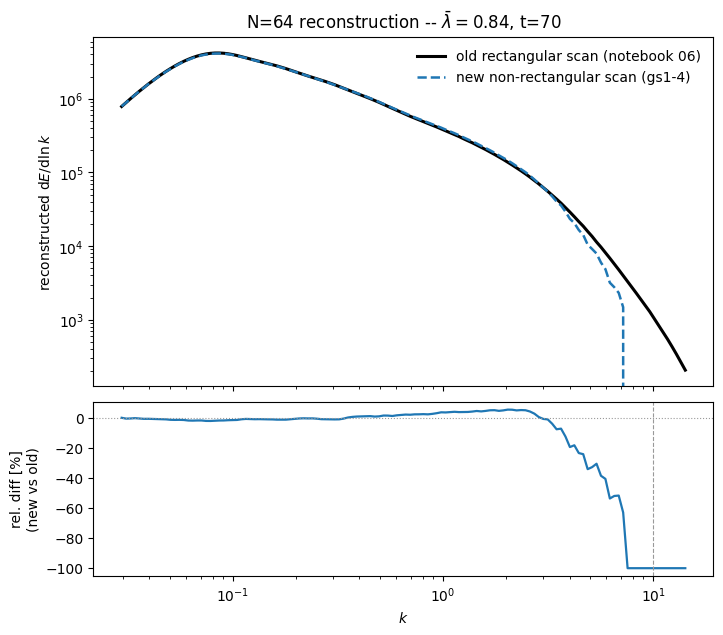

In [8]:
fig, (ax_spec, ax_diff) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                                       gridspec_kw=dict(height_ratios=[2, 1], hspace=0.06))

ax_spec.plot(k_out, old_recon, color='k', lw=2.2, label='old rectangular scan (notebook 06)')
ax_spec.plot(k_out, new_recon, color='C0', lw=1.8, ls='--',
            label='new non-rectangular scan (gs1-4)')
ax_spec.set_xscale('log')
ax_spec.set_yscale('log')
ax_spec.set_ylabel(r'reconstructed $\mathrm{d}E/\mathrm{d}\ln k$')
ax_spec.set_title(rf'N=64 reconstruction -- $\bar{{\lambda}}={LAMBDA_BAR}$, t={T_TARGET:.0f}')
ax_spec.legend(frameon=False)

rd = np.where(old_recon > 0, (new_recon - old_recon) / old_recon, np.nan)
ax_diff.plot(k_out, rd * 100, color='C0', lw=1.6)
ax_diff.axhline(0, color='0.6', lw=0.8, ls=':')
ax_diff.axvline(new_gammas.max(), color='0.6', lw=0.8, ls='--')
ax_diff.set_xscale('log')
ax_diff.set_xlabel(r'$k$')
ax_diff.set_ylabel('rel. diff [%]\n(new vs old)')

plt.tight_layout()
plt.savefig(REPO_ROOT / 'n64_reconstruction_scan_comparison.pdf', bbox_inches='tight')
plt.show()